# Real Estate House Price Prediction - Full EDA & Regression Analysis

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df = pd.read_csv("RealEstate HousePrice Dataset.csv")

df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [55]:
print("Shape of dataset:", df.shape)

df.info()

df.describe()

Shape of dataset: (4200, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


In [56]:
df.isnull().sum()

house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64

In [57]:
df = df.dropna()

In [ ]:
# Independent and Dependent Variables

X = df.drop("house_price_inr", axis=1)
y = df["house_price_inr"]

print("Independent Variables:\n", X.head())
print("Target Variable:\n", y.head())

Independent Variables:
    house_id  area_sqft  bedrooms  bathrooms  location_score  age_years  \
0    100001       1973         5          4             7.6         23   
1    100002       1560         3          3             6.3         13   
2    100003       2071         4          3             5.8          9   
3    100004       2640         5          3             7.7         12   
4    100005       1498         3          3             3.8         15   

   distance_city_km  lot_size_sqft  has_garage  has_pool  renovation_years_ago  
0              11.9           5220           1         0                     0  
1              15.8           3882           1         0                    13  
2              21.1           4488           0         0                     9  
3               7.9           3614           1         1                     4  
4              24.0           2663           0         0                    15  
Target Variable:
 0    40275084
1    26812029

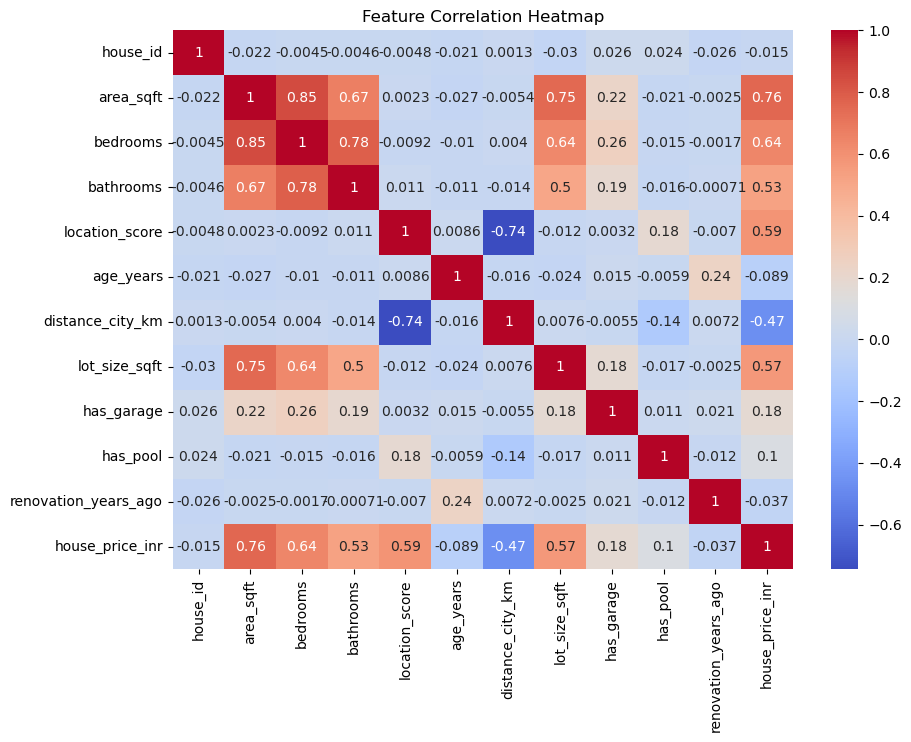

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

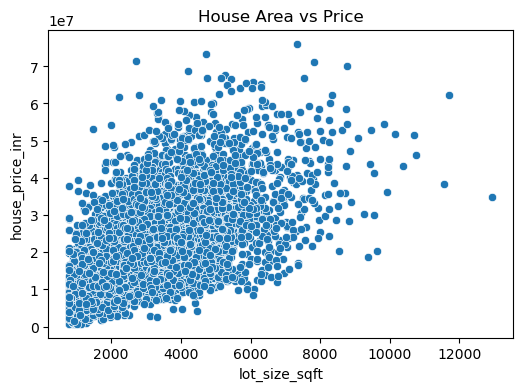

In [60]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["lot_size_sqft"], y=df["house_price_inr"])
plt.title("House Area vs Price")
plt.show()

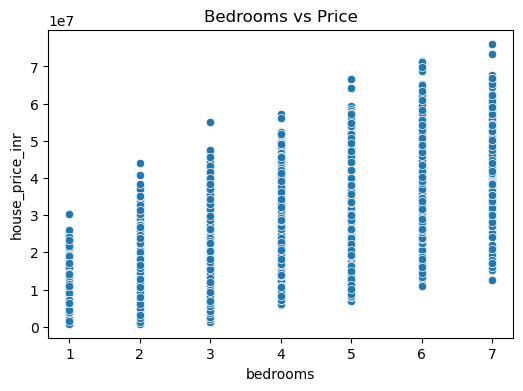

In [61]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["bedrooms"], y=df["house_price_inr"])
plt.title("Bedrooms vs Price")
plt.show()

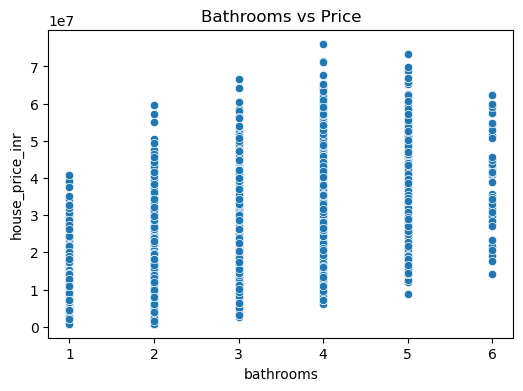

In [62]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["bathrooms"], y=df["house_price_inr"])
plt.title("Bathrooms vs Price")
plt.show()

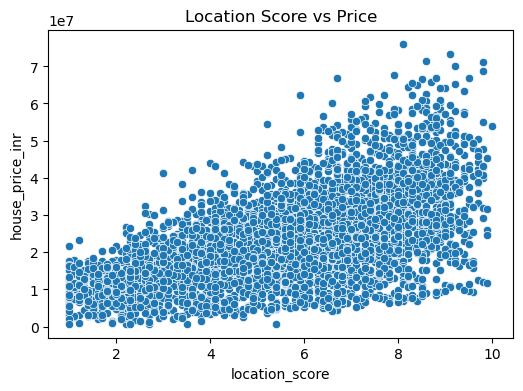

In [63]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["location_score"], y=df["house_price_inr"])
plt.title("Location Score vs Price")
plt.show()  

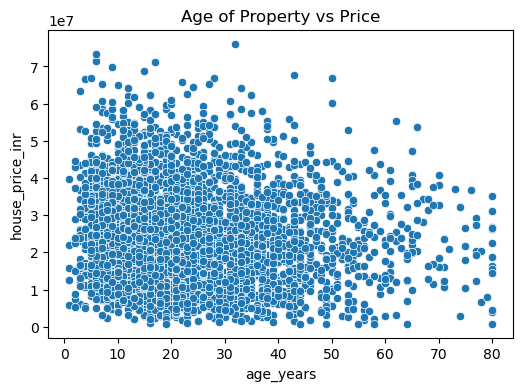

In [71]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["age_years"], y=df["house_price_inr"])
plt.title("Age of Property vs Price")
plt.show()

Distribution of Target Variable

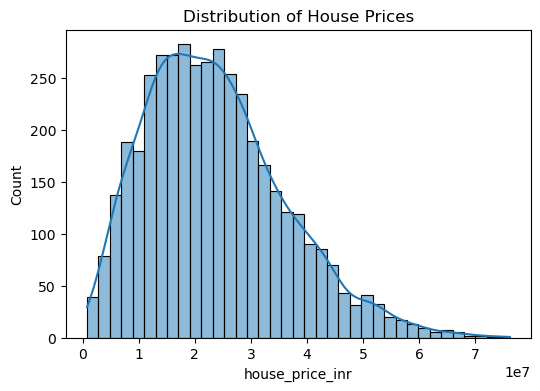

In [67]:
plt.figure(figsize=(6,4))
sns.histplot(df["house_price_inr"], kde=True)
plt.title("Distribution of House Prices")
plt.show()  

Train Test Split

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (3360, 11)
Testing Data: (840, 11)


In [69]:
df.to_csv("Final Cleaned Dataset.csv", index=False)
